In [4]:
!pip install numpy matplotlib

  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.3 MB 10.5 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.3 MB 20.6 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 

In [2]:
#importando bibliotecas

import numpy as np
import matplotlib.pyplot as plt

In [3]:
#lendo o arquivo 
dados = np.genfromtxt('artificial1d.csv', delimiter=',')

#Criando x e y (variáveis independentes e variáveis dependentes - colunas do arquivo)
x = dados[:, [0]] #primera coluna - variáveis independentes
y = dados[:,[1]] #segunda coluna - variáveis dependentes

Questao 01 - Letra A - Solução OLS

In [4]:
# y = w0 + w1x -> y = (wo * 1) + (w1 * 1)
# criando um matriz coluna de 1s e juntando com a matriz x para multiplicar 
n = x.shape[0] #numero de linhas
coluna_uns = np.ones((n,1)) #cria uma matriz coluna com n linhas
x_matriz = np.c_[coluna_uns, x] #junta as duas matrizes para poder multiplicar na formula do ols

#solução OLS : w = (X^T * X)^-1 * X^T * y
w = np.linalg.inv(x_matriz.T @ x_matriz) @ x_matriz.T @ y

#mostrando os parâmetros
print("Parâmetros Encontrados:")
print("w0:", w[0][0])
print("w1:", w[1][0])

#Encontrando o MSE
y_prediçao = x_matriz @ w
mse = np.mean((y - y_prediçao) **2) 
print("MSE:", mse)


Parâmetros Encontrados:
w0: 0.06761792463834031
w1: 1.5748651690368314
MSE: 0.21340090132936987


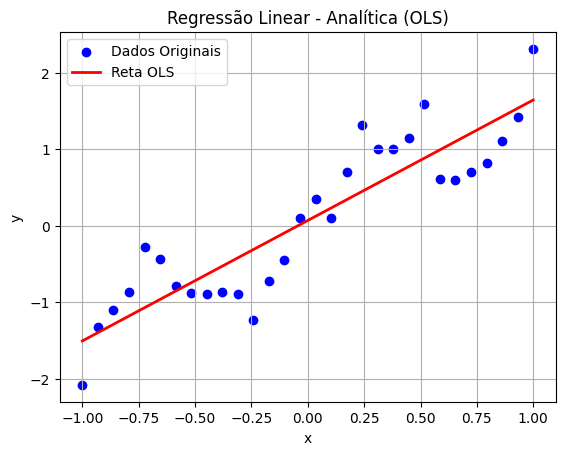

In [5]:
#Gerando o gráfico
plt.scatter(x, y, color='blue', label='Dados Originais') #criando os pontos soltos dos dados
plt.plot(x, y_prediçao, color='red', linewidth=2, label='Reta OLS') # desenha a reta 
plt.title("Regressão Linear - Analítica (OLS)") # cria o título
plt.xlabel("x") #coloca nome no eixo x
plt.ylabel("y") #coloca nome no eixo y
plt.legend() #cria caixa com legenda 
plt.grid(True) #cria uma grade no fundo
plt.show() # mostrar o gráfico 

Questão 01 - Letra B - Gradiente Descendente (GD)

In [6]:
#Já temos x, y, y_prediçao, x_matriz e n na memória

#1.  Escolha um valor α positivo e pequeno.
alpha = 0.01 #passo de aprendizado

#2. Inicialize os parâmetros do modelo na iteracão t = 0
epocas = 1000 #quantas vezes vamos rodar o loop e "aprender"
w = np.zeros((2,1)) #iniciando com w0 e w1 igual a 0

historico_mse = [] #guardando o erros -> para criar a curva de aprendizagem

#Repita por diversas iteraçoes (épocas): -> loop de treinamento (onde a máquina aprende)
for epoca in range(epocas):

    #Calcule os erros do modelo:
    y_prediçao = x_matriz @ w
    erro = y - y_prediçao

    #Calculando o MSE e guardando na lista
    mse = np.mean((erro)**2)
    historico_mse.append(mse)


    #Atualize os parâmetros:
    w = w + alpha * (1/n) * (x_matriz.T @ erro)  
    #linha 0: somatório de Ei
    #linha 1: somatório de Ei*Xi

#Encontrando os parâmetros
print("Parâmetros Encontrados no GD:")
print("w0:", w[0][0])
print("w1:", w[1][0])
print("MSE Final", historico_mse[-1]) #o ultimo numero da lista -> erro da ultima epoca, ja aprendeu tudo q podia


Parâmetros Encontrados no GD:
w0: 0.06761500548818636
w1: 1.530504947053618
MSE Final 0.21410710564525054


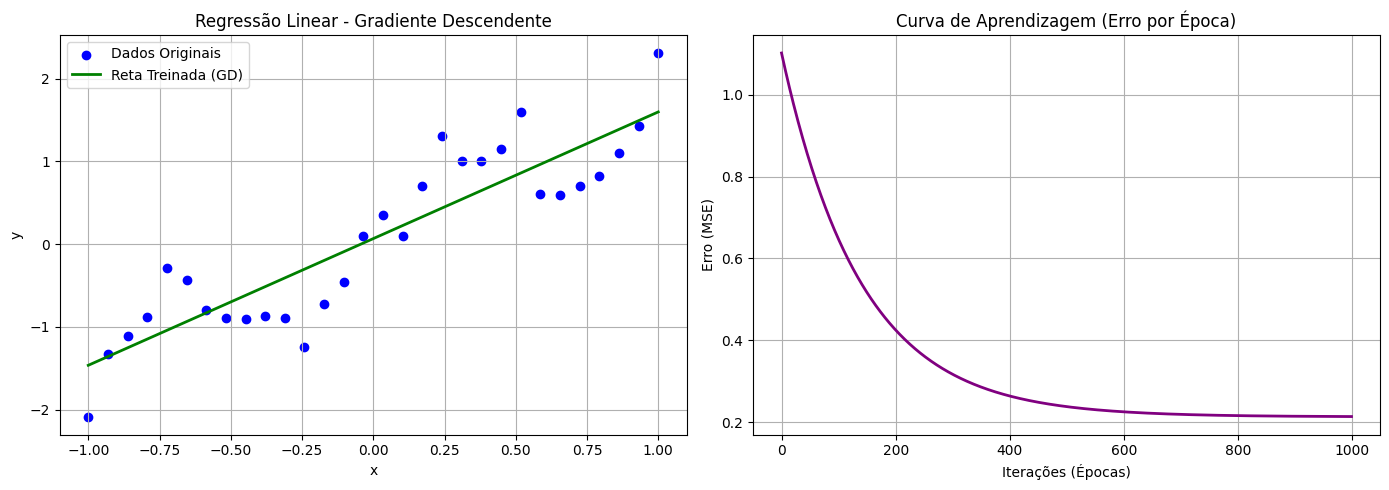

In [7]:
#Criando gráficos:
plt.figure(figsize=(14, 5))

#Gráfico 1
plt.subplot(1, 2, 1) #dividir a tela em dois
y_pred_final = x_matriz @ w
plt.scatter(x, y, color='blue', label='Dados Originais')
plt.plot(x, y_pred_final, color='green', linewidth=2, label='Reta Treinada (GD)')
plt.title("Regressão Linear - Gradiente Descendente")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

#Gráfico 2 - Curva de Aprendizem
plt.subplot(1, 2, 2) 
plt.plot(range(epocas), historico_mse, color='purple', linewidth=2)
plt.title("Curva de Aprendizagem (Erro por Época)")
plt.xlabel("Iterações (Épocas)")
plt.ylabel("Erro (MSE)")
plt.grid(True)

plt.tight_layout() 
plt.show()

Questão 01 - Letra C - Gradiente Descendente Estocástico (SGD)

In [9]:
#Escolha um valor α positivo e pequeno.
alpha_sgd = 0.01 #valor menor que o alpha do GD->passo menor

#Inicialize os parâmetros do modelo na iteração t = 0.
w_sgd = np.zeros((2,1)) 
epocas_sgd = 100 #menos epocas q o GD normal
historico_mse_sgd = []

#Treinamento
for epoca in range(epocas_sgd): #rodando todas as epocas
    for i in range(n): #rodando cada ponto

        xi = x_matriz[i:i+1, :] #pra continuar como uma array bidimensional 
        yi = y[i:i+1]

        #Calcule os erros do modelo:
        y_pred_i = xi @ w_sgd
        erro_i = yi- y_pred_i

        #calculando o MSE
        mse_passo = np.mean(erro_i**2)
        historico_mse_sgd.append(mse_passo)

        #Atualize os parâmetros:
        w_sgd = w_sgd + alpha_sgd * (xi.T @ erro_i) #erro nessa amostra

      

#Encontrando os parâmetros
print("Parâmetros encontrados:")
print("w0:", w_sgd[0][0])
print("w1:", w_sgd[1][0])
print("MSE final(SGD):", historico_mse_sgd[-1])

Parâmetros encontrados:
w0: 0.06707156871965195
w1: 1.5752632627081027
MSE final(SGD): 0.463931755801508


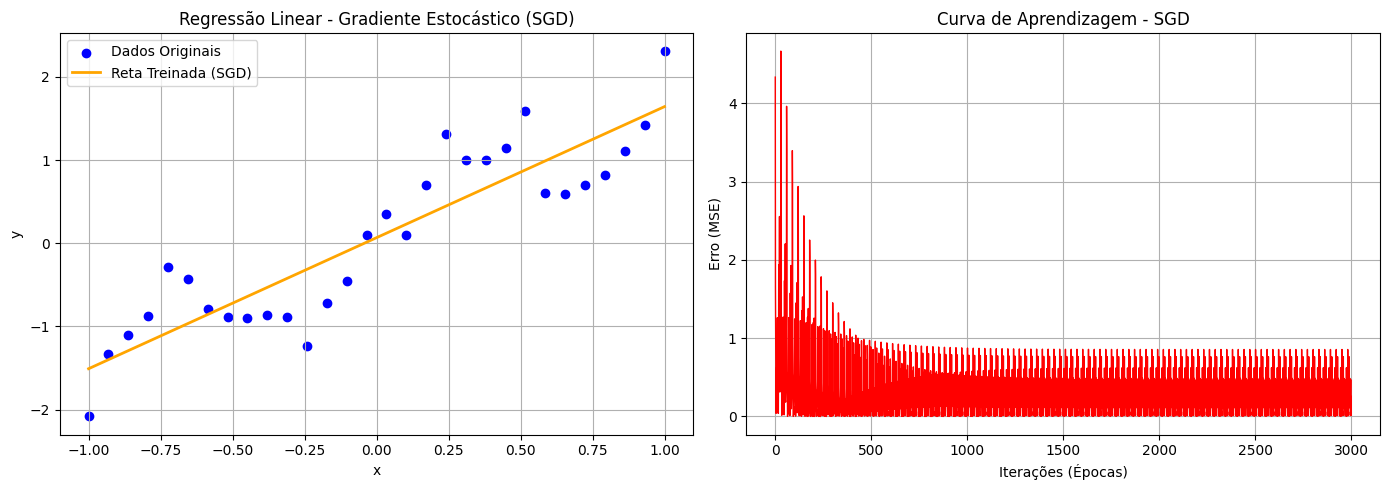

In [10]:
plt.figure(figsize=(14, 5))

# Gráfico Reta
plt.subplot(1, 2, 1) 
y_pred_final_sgd = x_matriz @ w_sgd
plt.scatter(x, y, color='blue', label='Dados Originais')
plt.plot(x, y_pred_final_sgd, color='orange', linewidth=2, label='Reta Treinada (SGD)')
plt.title("Regressão Linear - Gradiente Estocástico (SGD)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

# Grágico Curva de Aprendizem
plt.subplot(1, 2, 2) 
plt.plot(range(len(historico_mse_sgd)), historico_mse_sgd, color='red', linewidth=1)
plt.title("Curva de Aprendizagem - SGD")
plt.xlabel("Iterações (Épocas)")
plt.ylabel("Erro (MSE)")
plt.grid(True)

plt.tight_layout() 
plt.show()

Questão 02 - Regularização - Regressão Polinomial

In [11]:
!pip install scikit-learn
!pip install pandas

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

In [13]:
dados = np.genfromtxt('california.csv', delimiter=',', skip_header=1)
x = dados[:, :-1] #pega todas as linhas e até a última coluna
y = dados[:, -1].reshape(-1, 1) #pega todas as linhas e apenas a ultima coluna e deixa y em pé
n = x.shape[0] #quantas dados tem em cada coluna

#Normalização
scaler_X = MinMaxScaler() #deixa entre 0 e 1 -> normalizado - cria um teto para X
scaler_y = StandardScaler() #usa a fórmula z-score -> não limita o máximo, cresce naturalmente -> media 0 variac. 1

#normalizando os dados agora
x_norm = scaler_X.fit_transform(x) #ver min e max e "espremer" entre 0 e 1
y_norm = scaler_y.fit_transform(y) #ver média e desvio e subtrai de cada valor y

Item A - Dividindo em treino e teste

In [14]:
#Dividindo em treino e teste
x_treinamento, x_teste, y_treinamento, y_teste = train_test_split(
    x_norm, 
    y_norm, 
    test_size=0.20, 
    random_state=42 # O random_state garante que o "aleatório" é sempre igual se rodar de novo -> os mesmos numeros selecionados, pra não haver duvida de que oq estamos analisando é o modelo
)

#Confirmando os dados
print("Total de casas:", n)
print("Casas para treinamente:", x_treinamento.shape[0])
print("Casas para teste:", x_teste.shape[0])

Total de casas: 999
Casas para treinamente: 799
Casas para teste: 200


Item B e C - Treinamento com OLS e RMSE

RMSE Treino: 0.62860420876441
RMSE Teste: 0.8214798298185615
RMSE Treino: 0.6073465573427372
RMSE Teste: 0.8003641797423996
RMSE Treino: 0.5836263168533905
RMSE Teste: 0.9935590927295435
RMSE Treino: 0.5779118403039
RMSE Teste: 1.1255070365301165
RMSE Treino: 0.5678974200208072
RMSE Teste: 102.69599140505936
RMSE Treino: 0.5585421421208087
RMSE Teste: 869.0042481938218
RMSE Treino: 0.555591943529198
RMSE Teste: 4760.746769398777
RMSE Treino: 0.5514714579708523
RMSE Teste: 13967.57119215454
RMSE Treino: 0.5487504128039312
RMSE Teste: 342372.1895900701
RMSE Treino: 0.5442053958680186
RMSE Teste: 25678296.451641817
RMSE Treino: 0.5420212461694833
RMSE Teste: 61836171.72846046
RMSE Treino: 1.0715371493398187
RMSE Teste: 202548766.72823456
RMSE Treino: 3.5999088359208766
RMSE Teste: 3006148666.974708


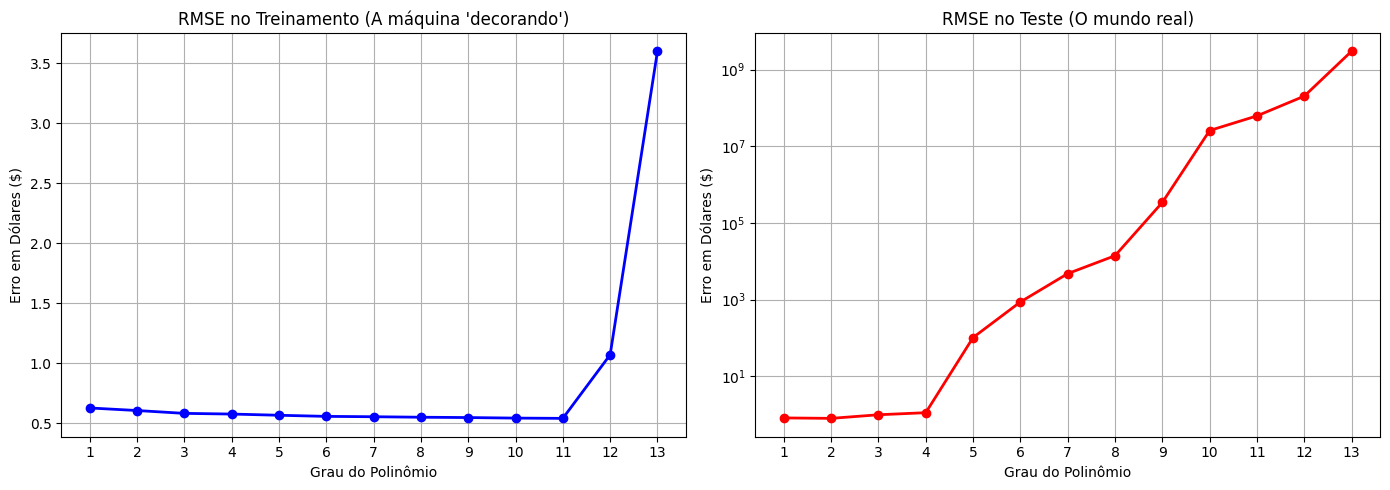

In [16]:
#Lista para guardar os erros
rmse_treino_lista= []
rmse_teste_lista= []
graus = list(range(1, 14))

for grau in graus:

    #criando as matrizes com a coluna de 1s
    x_treinamento_polinomial = np.ones((x_treinamento.shape[0], 1))
    x_teste_polinomial  = np.ones((x_teste.shape[0], 1))

    #adicionando as colunas elevadas à potência p
    for p in range(1, grau + 1):
        x_treinamento_polinomial = np.hstack((x_treinamento_polinomial, x_treinamento ** p))
        x_teste_polinomial  = np.hstack((x_teste_polinomial, x_teste ** p))
    
    #algoritmo ols
    w = np.linalg.inv(x_treinamento_polinomial.T @ x_treinamento_polinomial) @ x_treinamento_polinomial.T @ y_treinamento

    #previsões
    y_pred_treinamento_norm = x_treinamento_polinomial @ w
    y_pred_teste_norm = x_teste_polinomial @ w

    #desnormalizar
    y_treinamento_real= scaler_y.inverse_transform(y_treinamento)
    y_pred_treinamento_real = scaler_y.inverse_transform(y_pred_treinamento_norm)
    
    y_teste_real       = scaler_y.inverse_transform(y_teste)
    y_pred_teste_real  = scaler_y.inverse_transform(y_pred_teste_norm)

    #cálculo do RMSE -> RAIZ DO MSE
    rmse_treinamento = np.sqrt(np.mean((y_treinamento_real - y_pred_treinamento_real)**2))
    rmse_teste  = np.sqrt(np.mean((y_teste_real - y_pred_teste_real)**2))

    #mostrando na tela
    print("RMSE Treino:", rmse_treinamento)
    print("RMSE Teste:", rmse_teste)

    #anotando o rmse
    rmse_treino_lista.append(rmse_treinamento)
    rmse_teste_lista.append(rmse_teste)

plt.figure(figsize=(14, 5))

# Gráfico 1: O Erro no TREINO 
plt.subplot(1, 2, 1)
plt.plot(graus, rmse_treino_lista, marker='o', color='blue', linewidth=2)
plt.title("RMSE no Treinamento (A máquina 'decorando')")
plt.xlabel("Grau do Polinômio")
plt.ylabel("Erro em Dólares ($)")
plt.xticks(graus)
plt.grid(True)

# Gráfico 2: O Erro no TESTE
plt.subplot(1, 2, 2)
plt.plot(graus, rmse_teste_lista, marker='o', color='red', linewidth=2)
plt.title("RMSE no Teste (O mundo real)")
plt.xlabel("Grau do Polinômio")
plt.ylabel("Erro em Dólares ($)")
plt.xticks(graus)
plt.yscale('log') # Usamos escala logarítmica porque o erro nos graus altos explode muito!
plt.grid(True)

plt.tight_layout()
plt.show()





Item d - Regularização

RMSE Treino: 0.6286130428548107
RMSE Teste: 0.8212163223941825
RMSE Treino: 0.6075554855913354
RMSE Teste: 0.8010939825994532
RMSE Treino: 0.5899580983343605
RMSE Teste: 0.8022872979686694
RMSE Treino: 0.5874028888719455
RMSE Teste: 0.8102752652655698
RMSE Treino: 0.5865991731010846
RMSE Teste: 0.8184602599672817
RMSE Treino: 0.5861451961498756
RMSE Teste: 0.8242563487209057
RMSE Treino: 0.5855922771836032
RMSE Teste: 0.8264701025526214
RMSE Treino: 0.5848358175289251
RMSE Teste: 0.8262113454588815
RMSE Treino: 0.5839709225631343
RMSE Teste: 0.8249802927746422
RMSE Treino: 0.5831661229628445
RMSE Teste: 0.8238102450321231
RMSE Treino: 0.5825255077409085
RMSE Teste: 0.8231491057086191
RMSE Treino: 0.5820691617333043
RMSE Teste: 0.8230439022972477
RMSE Treino: 0.5817743391267562
RMSE Teste: 0.8233726957957429


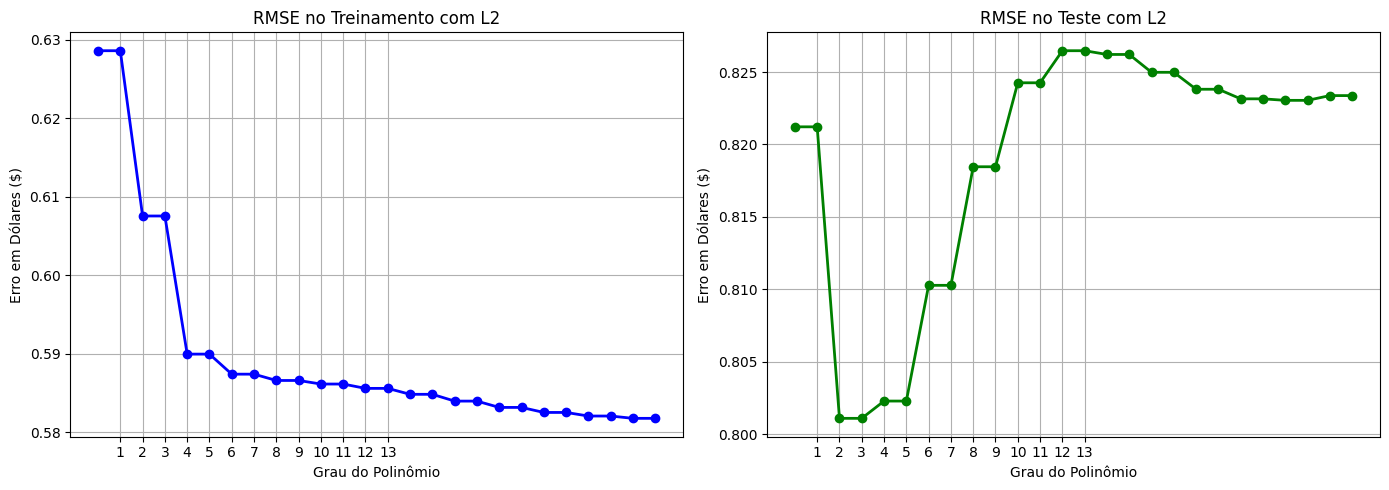

In [19]:
rmse_treino_lista = []
rmse_teste_lista = []
graus = list(range(1, 14))

lamb = 0.01 

for grau in graus:
    
    #criando as matrizes com a coluna de 1s
    x_treinamento_polinomial = np.ones((x_treinamento.shape[0], 1))
    x_teste_polinomial  = np.ones((x_teste.shape[0], 1))
    
    #adicionando as colunas elevadas à potência p
    for p in range(1, grau + 1):
        x_treinamento_polinomial = np.hstack((x_treinamento_polinomial, x_treinamento ** p))
        x_teste_polinomial  = np.hstack((x_teste_polinomial, x_teste ** p))
        
    #Algoritmo OLS regularizado
    #criando uma matriz identidade com o tamanho das nossas colunas
    num_colunas = x_treinamento_polinomial.shape[1]
    matriz_I = np.eye(num_colunas)
    
    #para não regularizar o w0 -> o 1º elemento é zero.
    matriz_I[0, 0] = 0 
    
    #w = (X^T*X + lambda*I)^-1 * X^T*y
    w = np.linalg.pinv(x_treinamento_polinomial.T @x_treinamento_polinomial + lamb * matriz_I) @ x_treinamento_polinomial.T @ y_treinamento
    
    #previsões
    y_pred_treinamento_norm = x_treinamento_polinomial @ w
    y_pred_teste_norm = x_teste_polinomial @ w
    
    #desnormalizando
    y_pred_treinamento_real = scaler_y.inverse_transform(y_pred_treinamento_norm)
    y_pred_teste_real= scaler_y.inverse_transform(y_pred_teste_norm)
    
    y_teste_real = scaler_y.inverse_transform(y_teste)
    y_pred_teste_real = scaler_y.inverse_transform(y_pred_teste_norm)

    # RMSE
    rmse_treinamento = np.sqrt(np.mean((y_treinamento_real - y_pred_treinamento_real)**2))
    rmse_teste = np.sqrt(np.mean((y_teste_real - y_pred_teste_real)**2))
    
    rmse_treino_lista.append(rmse_treinamento)
    rmse_teste_lista.append(rmse_teste)

    #mostrando na tela
    print("RMSE Treino:", rmse_treinamento)
    print("RMSE Teste:", rmse_teste)

    #anotando o rmse
    rmse_treino_lista.append(rmse_treinamento)
    rmse_teste_lista.append(rmse_teste)
    


plt.figure(figsize=(14, 5))

# Gráfico 1: Treino (L2)
plt.subplot(1, 2, 1)
plt.plot(range(len(rmse_treino_lista)), rmse_treino_lista, marker='o', color='blue', linewidth=2)
plt.title("RMSE no Treinamento com L2")
plt.xlabel("Grau do Polinômio")
plt.ylabel("Erro em Dólares ($)")
plt.xticks(graus)
plt.grid(True)

# Gráfico 2: Teste (L2)
plt.subplot(1, 2, 2)
plt.plot(range(len(rmse_teste_lista)), rmse_teste_lista, marker='o', color='green', linewidth=2)
plt.title("RMSE no Teste com L2")
plt.xlabel("Grau do Polinômio")
plt.ylabel("Erro em Dólares ($)")
plt.xticks(graus)
#agora não precisa do log
plt.grid(True)

plt.tight_layout()
plt.show()